In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [5]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [6]:
cplot.general()

### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [5]:
s0val = [0.1, 1]

Finding a profile with nodes: [0 0 0]
Final precision: U0 = [0.09185798 0.         0.        ] radius 67.98262417694264


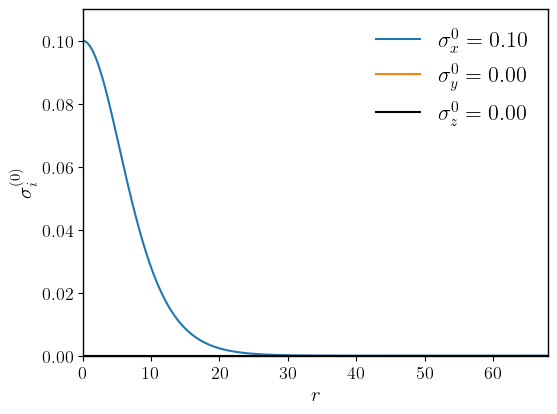

Finding a profile with nodes: [0 0 0]
Final precision: U0 = [0.91857977 0.         0.        ] radius 22.320763826002846


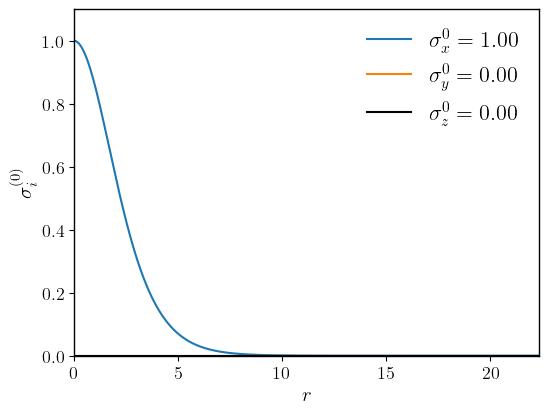

In [8]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx, ny, nz = 0, 0, 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx, ny, nz]  # list of node info

p1x = 0  # the first derivative value (p1x), the latter is zero
p0y, p1y = 0, 0  # The same in y-axes
p0z, p1z = 0, 0  # The same in z-axes
u1x, u1y, u1z = 0, 0, 0  # The first derivatives of the x, y, and z effective potential components are all zero.

rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
Uyint = [0, 0]
Uzint = [0, 0]
Uintrs = [Uxint, Uyint, Uzint]
numFields = len(Uintrs)

met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13 
Atol = 1e-15

datos = []
for p0x in s0val:  # The central amplitude of \sigma_x (p0x) and
    Ini0 = [p0x, p1x, p0y, p1y, p0z, p1z, u1x, u1y, u1z]  # boundary conditions list
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)
    
    #[U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT]
    datos.append([u0Val[0], u0Val[1], u0Val[2], rTmax, [p0x, p0y, p0z], nodos, LambT])

In [7]:
# datos

67.98262417694264
Stop [2.9473701e-10 0.0000000e+00 0.0000000e+00] k 500 ck [0.09185798 0.         0.        ]


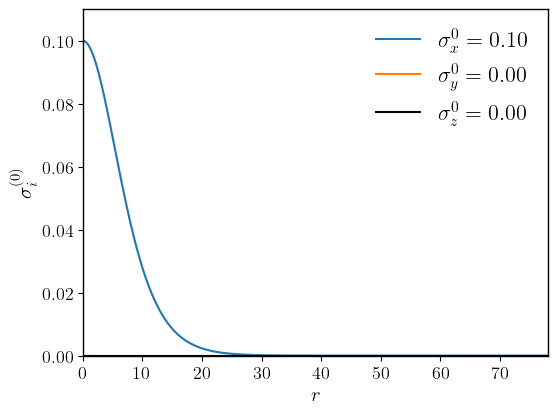

22.320763826002846
Stop [3.23377759e-07 0.00000000e+00 0.00000000e+00] k 500 ck [0.91857977 0.         0.        ]


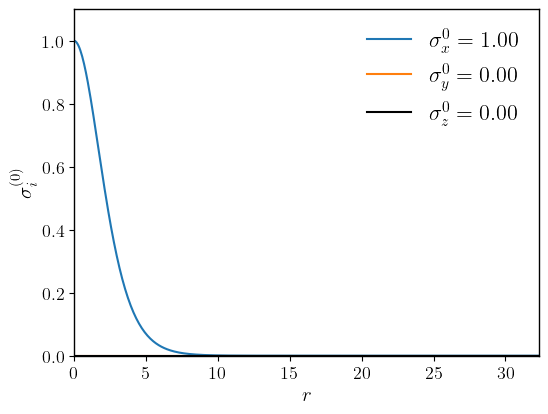

In [9]:
# Improving the previous results
confidata = []
for datinf in datos:
    U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT = datinf
    print(rTmax)

    rext = 10  # increasing the rTmax iteration radius
    rmin, rmax = 0, rTmax + rext
    limit = [rmin, rmax]

    p1x, p1y, p1z, u1x, u1y, u1z = 0, 0, 0, 0, 0, 0  # first derivatives

    uk = [U0x, U0y, U0z]  #  seeds

    # solving
    V0X = [p0x, p1x, p0y, p1y, p0z, p1z, None, u1x, None, u1y, None, u1z]
    V0Duk = np.zeros(12*3)
    V0Duk[6] = 1
    V0Duk[20] = 1
    V0Duk[-2] = 1
    V0 = np.concatenate((V0X, V0Duk))

    # Boolenos
    indck = np.concatenate(([False, False, False, False, False, False, True, False, True, False, True, False], [False]*36))
    V0[indck] = uk

    BCind = [0, 0, 0]

    indXc = np.array([False]*48)
    indXc[:5:2] = True 

    inddXc = np.array([False]*48)
    inddXc[12::12] =  True
    inddXc[14::12] =  True
    inddXc[16::12] =  True

    arg = [LambT]

    met = 'DOP853'
    Rtol = 1e-13 
    Atol = 1e-15

    V0fit = bg.fitting(bg.systemMultFreqTot, V0, indck, indXc, BCind, inddXc, limit, argf=arg, tol=1e-14,
                   met=met, Rtol=Rtol, Atol=Atol)
    
    U0 = V0fit[:12]
    U0x, U0y, U0z = U0[6], U0[8], U0[10]
    confidata.append([U0x, U0y, U0z, rmax, [p0x, p0y, p0z], nodos, LambT])
    
    # plot
    arg = [LambT]
    cplot.plotPerf(U0, rmax, arg=arg,  met=met, Rtol=Rtol, Atol=Atol)

Mass values: [1.0967589010576848, 1.0967589010576848, 1.0967589010576848]
Eigenvalues of energy: [-0.09789591944870207, -0.18975389662915895, -0.18975389662915895]


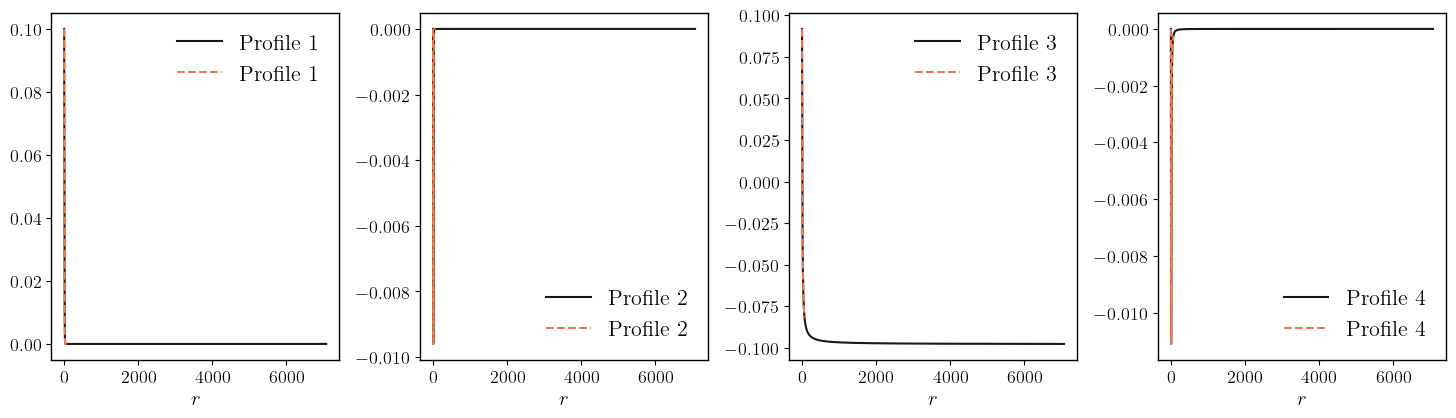

Mass values: [3.4682561713994113, 3.4682561713994113, 3.4682561713994113]
Eigenvalues of energy: [-0.9789591944862266, -1.897538966290849, -1.897538966290849]


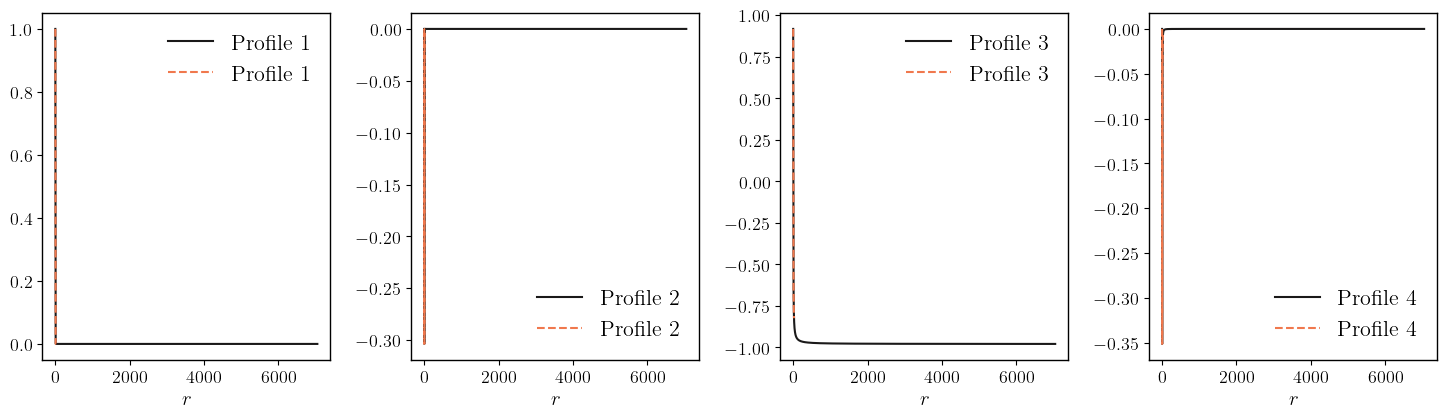

In [10]:
# Extendiendo los perfiles
Ext = 7000
Np = int(2e06)

confidataEx = []
for confi in datos: # confidata datos
    dataEx = bg.mainExt(confi, mult=True, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])

(1e-12, 1)

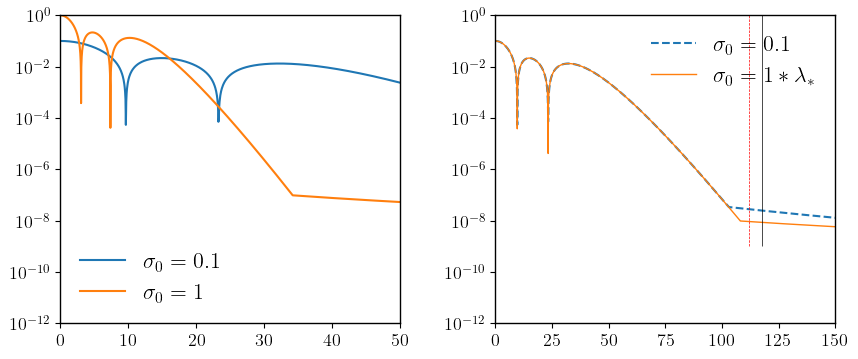

In [8]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=0.1$')
ax[0].plot(rDnew1, np.abs(sDnew1), label=r'$\sigma_0=1$')
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 50)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 1)
###########
ax[1].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=0.1$', ls='--')
lambdaSt = sDnew[0]
ax[1].plot(rDnew1/np.sqrt(lambdaSt), np.abs(sDnew1*lambdaSt), lw=1, label=r'$\sigma_0=1*\lambda_*$')
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 150)

ax[1].vlines(x=datos[0][3], ymin=1e-9, ymax=1, color='r', lw=0.5, ls='--')
ax[1].vlines(x=datos[1][3]/np.sqrt(lambdaSt),ymin=1e-9, ymax=1, color='k', lw=0.5, ls='-')

#ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[1].set_ylim(1e-12, 1)

In [9]:
# saving
temp = np.array(confidataEx[1], dtype="object")
np.save("sigma_0_1_LPn2", temp)

## Cargando perfiles

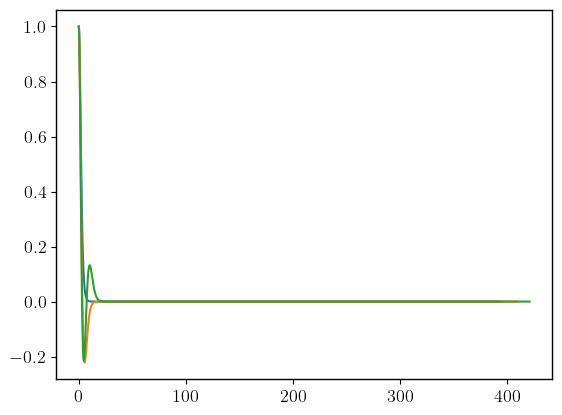

In [9]:
s01 = np.load("background_data_profiles_free_case/sigma_0_1_LP.npy", allow_pickle=True)
s01n1 = np.load("background_data_profiles_free_case/sigma_0_1_LPn1.npy", allow_pickle=True)
s01n2 = np.load("background_data_profiles_free_case/sigma_0_1_LPn2.npy", allow_pickle=True)

Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = s01
Ei1n1, rDnew1n1, sDnew1n1, dsDnew1n1, uDnew1n1, duDnew1n1 = s01n1
Ei1n2, rDnew1n2, sDnew1n2, dsDnew1n2, uDnew1n2, duDnew1n2 = s01n2

plt.plot(rDnew1, sDnew1)
plt.plot(rDnew1n1, sDnew1n1)
plt.plot(rDnew1n2, sDnew1n2)

## Stability 

In [10]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

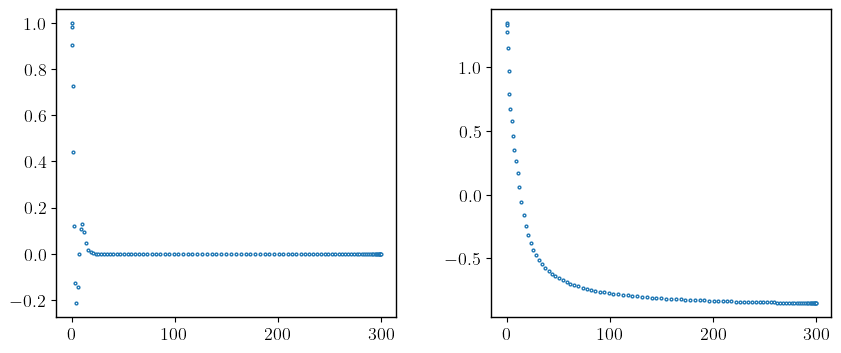

In [12]:
# Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01
# Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n1
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n2

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

J, Nptos, rMax = 0, 100, 300.
util = [J, Nptos, rMax]
lamV = [0, 0]
alp = 0.0

LambdaRealSorted, LambdaReal, eig_vectors_sorted, r_dis2 = sp.espectro(datFunc, util, lamV, alp, polariz, info=False, fplot=True)

In [13]:
jj = np.real(LambdaRealSorted)!=0
autoval2 = LambdaRealSorted[jj]

(-4.0, 4.0)

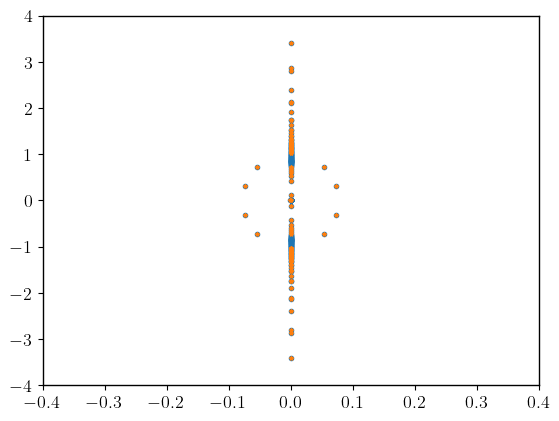

In [14]:
plt.plot(np.real(LambdaReal), np.imag(LambdaReal),'o', markersize=3)
plt.plot(np.real(autoval2), np.imag(autoval2),'*', markersize=3)

plt.xlim(-0.4, 0.4)
plt.ylim(-4, 4)

### Convergencia

In [7]:
import pandas as pd

In [26]:
# Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01
# Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n1
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n2

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

# Convergencia variando rMax para N fijo
Nptosdat = 300
Jdat = 0
rMaxVal = np.arange(100., 325., 25)

lamV = [0, 0]
alp = 1
colum_data2 = []
for rMax in rMaxVal:
    J, Nptos, rMax = Jdat, Nptosdat, rMax
    util = [J, Nptos, rMax]
    LambdaRealSorted, _, _, _ = sp.espectro(datFunc, util, lamV, alp, polariz, info=False, fplot=False)
    
    # extracting the reals eingevalues
    jj = np.real(LambdaRealSorted)!=0
    autoval2 = LambdaRealSorted[jj]
    
    autoval2 = np.insert(autoval2, 0, rMax, axis=None)  # add the rMax at 0 position
    colum_data2.append(autoval2)

# making the dataframe
datos_Autov2 = pd.DataFrame(colum_data2)

nameC2 = []
for colName in datos_Autov2:
    if colName==0:
        nameC2.append('N-value')
    else:
        nameC2.append(colName)
    
datos_Autov2.columns = nameC2  # poniendo nuevos nombres
datos_Autov2['N-value'] = abs(datos_Autov2['N-value'])  # pasando la columna de L a reales

In [27]:
# datos_Autov2

In [28]:
# Organizando los auto-valores
datos_Org = sp.Organize(datos_Autov2, Rtol=1e-02, Atol=1e-04)
datos_Org

The reference row is 4


,N-value,1,2,3,4,5,6,7,8,9,...,589,590,591,592,593,594,595,596,597,598
0,100.0,0.000675+0.000000j,-0.000675+0.000000j,-0.000000+0.111767j,0.000000-0.111767j,-0.074066+0.321823j,0.074066+0.321823j,-0.074066-0.321823j,0.074066-0.321823j,-0.000000-0.423793j,...,-0.000000+10885.926498j,0.000000-10885.926498j,0.000000+26610.871223j,-0.000000-26610.871223j,-0.000000-26613.035207j,0.000000+26613.035207j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
1,125.0,0.000556-0.000000j,-0.000556-0.000000j,0.000000+0.111767j,0.000000-0.111767j,-0.074066+0.321824j,0.074066+0.321824j,-0.074066-0.321824j,0.074066-0.321824j,0.000000-0.423793j,...,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
2,150.0,0.000483+0.000000j,-0.000483+0.000000j,-0.000000+0.111767j,0.000000-0.111767j,-0.074066+0.321823j,0.074066+0.321823j,-0.074066-0.321823j,0.074066-0.321823j,-0.000000-0.423793j,...,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
3,175.0,0.000746+0.000000j,-0.000746-0.000000j,-0.000000+0.111768j,-0.000000-0.111768j,-0.074066+0.321823j,0.074066+0.321823j,-0.074066-0.321823j,0.074066-0.321823j,0.000000-0.423793j,...,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
4,200.0,0.000684-0.000000j,-0.000684+0.000000j,0.000000+0.111768j,0.000000-0.111768j,-0.074066+0.321823j,0.074066+0.321823j,-0.074066-0.321823j,0.074066-0.321823j,0.000000-0.423793j,...,0.000000- 2722.119066j,-0.000000+ 2722.119066j,0.000000+ 6651.714636j,-0.000000- 6651.714636j,0.000000+ 6653.893633j,-0.000000- 6653.893633j,0.000000+38365.445653j,0.000000-38365.445653j,-0.000000+38367.921229j,-0.000000-38367.921229j
5,225.0,0.000576+0.000000j,-0.000576+0.000000j,-0.000000+0.111768j,0.000000-0.111768j,-0.074066+0.321823j,0.074066+0.321823j,-0.074066-0.321823j,0.074066-0.321823j,-0.000000-0.423793j,...,-0.000000+ 5257.578553j,0.000000- 5257.578553j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
6,250.0,0.000000-0.000134j,-0.000000+0.000134j,-0.000000+0.111766j,0.000000-0.111766j,-0.074066+0.321824j,0.074066+0.321824j,-0.074066-0.321824j,0.074066-0.321824j,0.000000-0.423793j,...,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
7,275.0,-0.000433-0.000000j,0.000433+0.000000j,-0.000000+0.111767j,0.000000-0.111767j,-0.074067+0.321823j,0.074067+0.321823j,-0.074067-0.321823j,0.074067-0.321823j,-0.000000-0.423793j,...,-0.000000+ 1440.206817j,0.000000- 1440.206817j,-0.000000+ 3517.629857j,0.000000- 3517.629857j,-0.000000+ 3519.822905j,0.000000- 3519.822905j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j,NaN+ 0.000000j
8,300.0,0.000601-0.000000j,-0.000601+0.000000j,0.000000+0.111766j,0.000000-0.111766j,-0.074067+0.321823j,0.074067+0.321823j,-0.074067-0.321823j,0.074067-0.321823j,0.000000-0.423793j,...,0.000000- 1210.312950j,-0.000000+ 1210.312950j,0.000000+ 2955.571727j,0.000000- 2955.571727j,-0.000000- 2957.768103j,0.000000+ 2957.768103j,0.000000+17050.598316j,-0.000000-17050.598316j,0.000000+17052.856199j,-0.000000-17052.856199j


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

(0.32181327984810043, 0.321835744327758)

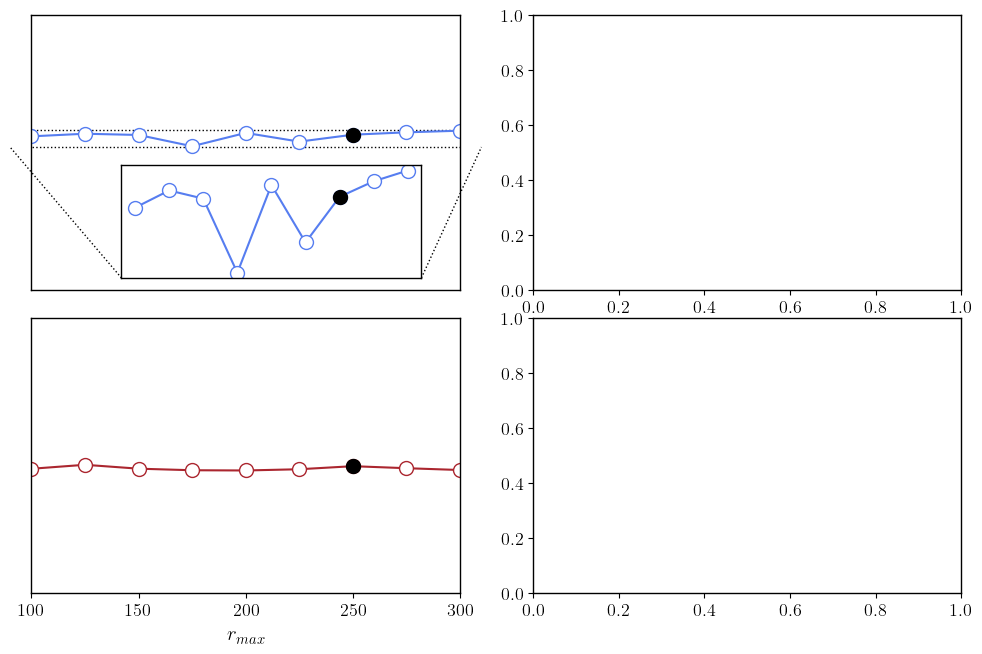

In [53]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 7.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
indices = [6]
for ii in indices:
    dR, dI = np.real(datos_Org[ii]), np.imag(datos_Org[ii])
    N_valu = np.array(datos_Org['N-value'])
    #ax[0][0].ticklabel_format(axis='y', style='sci', scilimits=(-7,8))

    ax[0][0].plot(N_valu,  np.abs(dR), '-', marker='o', mfc='white',
                  color = '#567df0', label = r'$\lambda_R\, (\mathsf{N})$')

    ax[1][0].plot(N_valu,  np.abs(dI), '-', marker='o', mfc='white', 
                  color = '#ab262f', label = r'$\lambda_I\, (\mathsf{N})$')

indiceUsado = 6
ax[0][0].plot(N_valu[indiceUsado],  np.abs(dR)[indiceUsado], ' ', marker='o', color = 'black', 
              label = r'$\lambda_R\, (\mathsf{N}=\mathrm{int}[3r_{\star}/4])$')
ax[1][0].plot(N_valu[indiceUsado],  np.abs(dI)[indiceUsado], ' ', marker='o', color = 'black', 
              label = r'$\lambda_I\, (\mathsf{N}=\mathrm{int}[3r_{\star}/4])$')

# añadiendo figuras insertadas, en este caso los términos métricos
left, bottom, width, height = [0.2, 0.53, 0.25, 0.15]  # posición y dimensiones del insert
ax1 = fig.add_axes([left, bottom, width, height]) # añadiendo el subplot y llamandolo ax2
# en caso de que quieras que los ejes usen notacion científica descomentar
ax1.ticklabel_format(axis='y', style='sci', scilimits=(-7,10))

ax1.plot(N_valu,  np.abs(dR), '-', marker='o',  mfc='white',
             color = '#567df0', label = r'n=%2.9f'%(np.abs(dR[-1])))

ax1.plot(N_valu[indiceUsado],  np.abs(dR)[indiceUsado], '-', marker='o', color = 'black')

#ax1.set_xlim(100, 370)
#ax1.set_ylim(0.0061939813, 0.00619398145)
ax1.set_yscale('log')
#ax1.set_ylabel(r'$B_I \, [c_1]$', labelpad=-2)
ax1.set_xticks([])
mark_inset(ax[0][0], ax1, loc1=3, loc2=4, fc="none", ec="0.", ls=':', color='black')


ax[0][0].set_yscale('log')
ax[1][0].set_yscale('log')

ax[1][0].set_xlabel(r'$r_{max}$', labelpad=5)

ax[0][0].set_xlim(100, 300)
ax[1][0].set_xlim(100, 300)

ax[0][0].set_xticks([])
ax[0][0].set_ylim(min(dR)-1.0e-5, max(dR)+.8e-5)
ax[1][0].set_ylim(min(dI)-1.0e-5, max(dI)+1.2e-5)